## Question 2: Predict Age from Face Images

You are provided with a face image dataset containing 2000 images of human faces. Your objective is to develop a regression model using PyTorch that accurately predicts the age of a person based on their face image.

You are provided with the code to download and load the dataset.

Your work will be evaluated based on the completion of the following tasks:


# 1. Load and Process Data (Provided)

### **1. Load and Process Data (Provided)**

The code below is provided for you. It:
1.  Loads images from the `images` folder.
2.  Loads labels from `labels.csv`.
3.  Splits the data into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`).

**Just run these cell to load the data.**

In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammad2012191/q2-ka-ai-2026")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/q2-ka-ai-2026


In [24]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

# Load Labels
labels_df = pd.read_csv(os.path.join(path, "labels.csv"))
img_dir = os.path.join(path, "images")

images = []
ages = []

# Load Images and Resize
print("Loading images...")
for index, row in labels_df.iterrows():
    img_name = row.iloc[0]
    age = row.iloc[1]
    img_path = os.path.join(img_dir, img_name)
    
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        img_array = np.array(img) / 255.0 # Normalize pixel values to [0, 1]
        images.append(img_array)
        ages.append(age)

X = np.array(images)
y = np.array(ages)

# Transpose image dimensions to match PyTorch format (N, C, H, W)
X = np.transpose(X, (0, 3, 1, 2))

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Loading images...
X_train shape: (1600, 3, 36, 36)
X_test shape: (400, 3, 36, 36)
y_train shape: (1600,)
y_test shape: (400,)


## **Part 1: Prepare Data for PyTorch**

**Tasks:**
1.  **Convert to Tensors:** Convert the numpy arrays (`X_train`, `X_test`, `y_train`, `y_test`) into PyTorch tensors.
2.  **Create Datasets:** Use `TensorDataset` to create `train_dataset` and `test_dataset` from the tensors.
3.  **Create DataLoaders:** Create `train_loader` and `test_loader` with a batch size of 32. 
4.  **Inspect Data:** Print the shape of one batch from the train loader and 
5.  **Display a few images:** Use matplotlib to display a few images.

In [25]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [26]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [27]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [28]:
images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

Batch images shape: torch.Size([32, 3, 36, 36])
Batch labels shape: torch.Size([32])


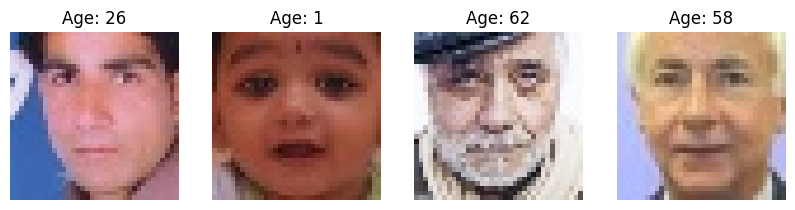

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"Age: {labels[i].item():.0f}")
    plt.axis("off")
plt.show()

# Part 2: Model

**Tasks:**

1. Create a model class with **4 linear layers**
2. Create a training loop function
3. Create a validation loop function
4. Define the device, model, loss function, and optimizer
5. Start training for **20 epochs** and track training and validation losses

In [30]:
import torch.nn as nn

class AgeModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(AgeModel, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, hidden_dim)
        self.layer4 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.layer4(x)
        return x.squeeze()

In [31]:
def train_one_epoch(model, optimizer, criterion, train_loader, device):
    # Set the model to training mode
    model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Move batch to the selected device
        X_batch = X_batch.view(X_batch.size(0), -1).to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Backward pass & optimization
        optimizer.zero_grad()   # Clear previous gradients
        loss.backward()         # Compute gradients
        optimizer.step()        # Update model parameters

        running_loss += loss.item()

    # Average loss over all batches
    avg_loss = running_loss / len(train_loader)

    return avg_loss

In [32]:
def validate(model, criterion, test_loader, device):
    # Set the model to evaluation mode
    model.eval()

    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            # Move data to device
            X_batch = X_batch.view(X_batch.size(0), -1).to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item()

    avg_loss = running_loss / len(test_loader)

    return avg_loss

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = 36 * 36 * 3
hidden_dim = 128
output_dim = 1

model = AgeModel(input_dim, hidden_dim, output_dim).to(device)

num_epochs = 20
learning_rate = 0.001

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), learning_rate)

In [37]:
# Run Training
train_losses = []
val_losses = []

print('Starting Training...')
for epoch in range(num_epochs):
    # Train one epoch
    train_loss = train_one_epoch(model, optimizer, criterion, train_loader, device)

    # Validate
    val_loss = validate(model, criterion, test_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

print('Training Complete!')

Starting Training...
Epoch [1/20], Train Loss: 680.7792, Val Loss: 541.6464
Epoch [2/20], Train Loss: 488.1496, Val Loss: 511.0973
Epoch [3/20], Train Loss: 441.1919, Val Loss: 467.0513
Epoch [4/20], Train Loss: 388.2188, Val Loss: 440.7660
Epoch [5/20], Train Loss: 332.2192, Val Loss: 353.4872
Epoch [6/20], Train Loss: 301.4877, Val Loss: 334.8264
Epoch [7/20], Train Loss: 293.9032, Val Loss: 293.7666
Epoch [8/20], Train Loss: 278.2906, Val Loss: 299.0000
Epoch [9/20], Train Loss: 250.3291, Val Loss: 253.3688
Epoch [10/20], Train Loss: 225.8422, Val Loss: 244.4755
Epoch [11/20], Train Loss: 216.7015, Val Loss: 228.6138
Epoch [12/20], Train Loss: 219.5328, Val Loss: 234.3903
Epoch [13/20], Train Loss: 212.7939, Val Loss: 224.6633
Epoch [14/20], Train Loss: 218.3071, Val Loss: 250.7143
Epoch [15/20], Train Loss: 205.6754, Val Loss: 228.0454
Epoch [16/20], Train Loss: 191.1338, Val Loss: 222.7227
Epoch [17/20], Train Loss: 190.4003, Val Loss: 208.2426
Epoch [18/20], Train Loss: 201.5132,

# Part 3: Plots

**Tasks:**

1. Plot the training and validation loss over epochs
2. **Bonus:** Plot some predictions with their actual images (show predicted age vs actual age)

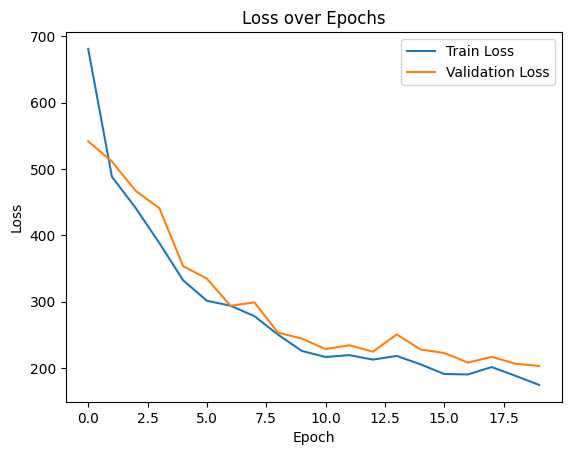

In [38]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

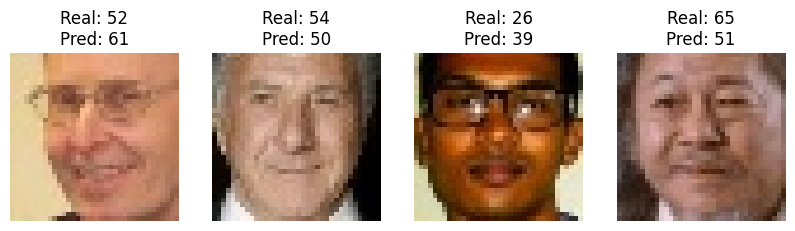

In [39]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
    preds = model(images.view(images.size(0), -1))

plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    img = images[i].cpu().permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"Real: {labels[i].item():.0f}\nPred: {preds[i].item():.0f}")
    plt.axis("off")
plt.show()